# Synthetic Parameter Recovery

Validates the full inference pipeline by generating synthetic data from known GP parameters\nand checking whether a grid search recovers those parameters.
## Pipeline
1. Fix ground-truth `(length_scale, mu_0)`
2. Sample pseudocoherences `y_train`, `y_test` from the GP prior
3. Sample utterances `u_train` from the RSA speaker given `y_train`
4. Sample synthetic prevalence ratings from the Beta mixture given `y_test`
5. Run a sparse grid search over `(length_scale, mu_0)`
6. Check that the best cell is near the true params"


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from itertools import product
from scipy.special import logsumexp as scipy_logsumexp

from model_jax import (
    rbf_kernel,
    p_u_given_y,
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

backend: cpu


## Ground-truth parameters and feature embeddings

In [2]:
# Ground-truth parameters to recover
TRUE_PARAMS = {
    'length_scale': 0.4,
    'mu_0':         0.0,
    'output_scale': 1.5,
    'beta':         3.0,
}

# Use real feature embeddings from the dataframe so geometry is realistic
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

TEST_FEATURE_NAMES = [
    'can eat spicy food', 'eat breakfast very late', 'eat five meals a day',
    'like juice with pulp', 'put pepper on all their foods',
    'cry easily', 'like to collect rocks', 'like to dance',
    'like to give high-fives', 'like to read books',
    'can roll their tongue', 'can snap with their toes',
    'can wiggle their ears', 'have cold hands and feet', 'snore when they sleep',
]

x_train = jnp.array(train_df[['x_2d', 'y_2d']].values)   # (45, 2)
x_test  = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in TEST_FEATURE_NAMES]
)  # (15, 2)

n_train = x_train.shape[0]
J       = x_test.shape[0]
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

x_train: (45, 2), x_test: (15, 2)


## Step 1: Sample pseudocoherences from the GP prior

In [3]:
rng = np.random.default_rng(37)

# Stack all features: test first then train (matches make_log_density_fn_joint convention)
X_all = jnp.vstack([x_test, x_train])   # (J + n_train, 2)
mu    = jnp.full(J + n_train, TRUE_PARAMS['mu_0'])
K     = rbf_kernel(X_all, TRUE_PARAMS['length_scale'], TRUE_PARAMS['output_scale'])

y_all = rng.multivariate_normal(np.array(mu), np.array(K))  # (J + n_train,)
y_test_true  = y_all[:J]           # (J,)       pseudocoherences for test features
y_train_true = y_all[J:]           # (n_train,) pseudocoherences for training features

pz1_test_true = 1 / (1 + np.exp(-y_test_true))   # (J,)

print(f"y_train range: [{y_train_true.min():.2f}, {y_train_true.max():.2f}]")
print(f"y_test  range: [{y_test_true.min():.2f}, {y_test_true.max():.2f}]")
print(f"pz1_test range: [{pz1_test_true.min():.2f}, {pz1_test_true.max():.2f}]")

y_train range: [-2.91, 0.06]
y_test  range: [-2.29, 0.11]
pz1_test range: [0.09, 0.53]


## Step 2: Sample utterances from RSA speaker

In [4]:
# For each training feature, sample P(u|y) from the speaker and draw one utterance
beta = TRUE_PARAMS['beta']
u_probs = np.array([
    float(p_u_given_y(0, float(y_i), beta))   # P(generic | y_i)
    for y_i in y_train_true
])  # (n_train,) — probability of generic utterance

# Sample: 0=generic, 1=specific
u_train_true = (rng.uniform(size=n_train) > u_probs).astype(np.int32)
u_train      = jnp.array(u_train_true)

print(f"Utterances: {(u_train_true==0).sum()} generic, {(u_train_true==1).sum()} specific")
print(f"P(generic) range: [{u_probs.min():.2f}, {u_probs.max():.2f}]")

Utterances: 15 generic, 30 specific
P(generic) range: [0.12, 0.51]


## Step 3: Sample synthetic prevalence ratings from the Beta mixture

responses: (100, 15)
empirical mean range: [0.22, 0.55]


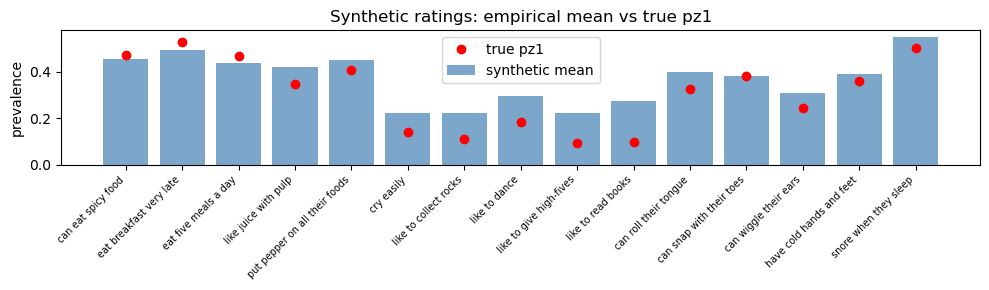

In [5]:
# Ground-truth Beta mixture params — use the same shape as the real data fits
# kind-linked component: Beta(5, 1) — high prevalence
# non-kind-linked component: Beta(1, 5) — low prevalence
ALPHA_KL, BETA_KL   = 5.0, 1.0
ALPHA_NKL, BETA_NKL = 1.0, 5.0

N_PARTICIPANTS = 100  # synthetic participants per test feature

ratings = np.zeros((N_PARTICIPANTS, J))
for j in range(J):
    pz1 = pz1_test_true[j]
    for n in range(N_PARTICIPANTS):
        # draw component assignment
        if rng.uniform() < pz1:
            ratings[n, j] = rng.beta(ALPHA_KL, BETA_KL)
        else:
            ratings[n, j] = rng.beta(ALPHA_NKL, BETA_NKL)

responses = jnp.array(ratings)  # (N, J)
N = N_PARTICIPANTS
print(f"responses: {responses.shape}")
print(f"empirical mean range: [{float(responses.mean(0).min()):.2f}, {float(responses.mean(0).max()):.2f}]")

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(J), np.array(responses.mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
ax.plot(range(J), pz1_test_true, 'ro', label='true pz1')
ax.set_xticks(range(J))
ax.set_xticklabels(TEST_FEATURE_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('prevalence')
ax.set_title('Synthetic ratings: empirical mean vs true pz1')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Diagnostic: check realized means of sampled pseudocoherences
# If the GP sample happened to land at a mean far from mu_0=0, the grid search
# will correctly find a shifted mu_0 — not a bug, just sampling variability.

print(f"True mu_0: {TRUE_PARAMS['mu_0']:.3f}  (prior mean of pseudocoherences)")
print(f"Realized y_train mean: {y_train_true.mean():.3f}  (std={y_train_true.std():.3f})")
print(f"Realized y_test  mean: {y_test_true.mean():.3f}  (std={y_test_true.std():.3f})")
print(f"Realized pz1_test mean: {pz1_test_true.mean():.3f}")
print(f"Empirical ratings mean: {float(responses.mean()):.3f}")
print()
print("If y_train/y_test mean is far from mu_0, the recovery shift is expected.")

True mu_0: 0.000  (prior mean of pseudocoherences)
Realized y_train mean: -1.120  (std=0.828)
Realized y_test  mean: -0.930  (std=0.817)
Realized pz1_test mean: 0.311
Empirical ratings mean: 0.368

If y_train/y_test mean is far from mu_0, the recovery shift is expected.


## Step 4: Sparse grid search over `(length_scale, mu_0)`

In [7]:
FIXED_PARAMS = {
    'output_scale': TRUE_PARAMS['output_scale'],
    'beta':         TRUE_PARAMS['beta'],
}

# Sparse grid — true params are ls=0.4, mu_0=0.0
LENGTH_SCALES = [0.2, 0.4, 0.6] # [0.1, 0.2, 0.4, 0.6, 0.7]
MU_0_VALS     = [-0.5, 0.0, 0.5]

N_WARMUP  = 500
N_SAMPLES = 2000
STEP      = 10   # thinning: 1999 → ~200 samples

print(f"Grid: {len(LENGTH_SCALES)} lengthscales × {len(MU_0_VALS)} mu_0 = {len(LENGTH_SCALES)*len(MU_0_VALS)} runs")
print(f"True params: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']}")

Grid: 3 lengthscales × 3 mu_0 = 9 runs
True params: ls=0.4, mu_0=0.0


In [8]:
results = []
total = len(LENGTH_SCALES) * len(MU_0_VALS)

for i, (ls, mu_0) in enumerate(product(LENGTH_SCALES, MU_0_VALS)):
    print(f"[{i+1:2d}/{total}] ls={ls:<5}  mu_0={mu_0:<5}", end="  ")

    params = {**FIXED_PARAMS, 'length_scale': ls, 'mu_0': mu_0}
    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(n_train),
        'test_coherences':     jnp.zeros(J),
    }

    rng_key = jax.random.PRNGKey(0)
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=N_WARMUP)

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, N_SAMPLES)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)

    log_liks_s = []
    for s in range(0, test_coherences_all.shape[0], STEP):
        pz1_s    = jnp.array(jax.nn.sigmoid(test_coherences_all[s]))
        pz1_s_bc = jnp.tile(pz1_s, (N, 1))
        beta_params_s = fit_beta_mixtures_all_features(responses, pz1_s_bc)
        log_liks_s.append(float(beta_mixture_log_likelihood(responses, pz1_s, beta_params_s)))

    log_lik = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
    print(f"log_lik={log_lik:.1f}")

    results.append({'length_scale': ls, 'mu_0': mu_0, 'log_lik': log_lik})

print("\nGrid search complete.")

[ 1/9] ls=0.2    mu_0=-0.5   

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


log_lik=483.2
[ 2/9] ls=0.2    mu_0=0.0    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


log_lik=485.7
[ 3/9] ls=0.2    mu_0=0.5    

...

log_lik=491.2
[ 8/9] ls=0.6    mu_0=0.0    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


log_lik=490.8
[ 9/9] ls=0.6    mu_0=0.5    

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


log_lik=490.9

Grid search complete.


## Step 5: Check parameter recovery

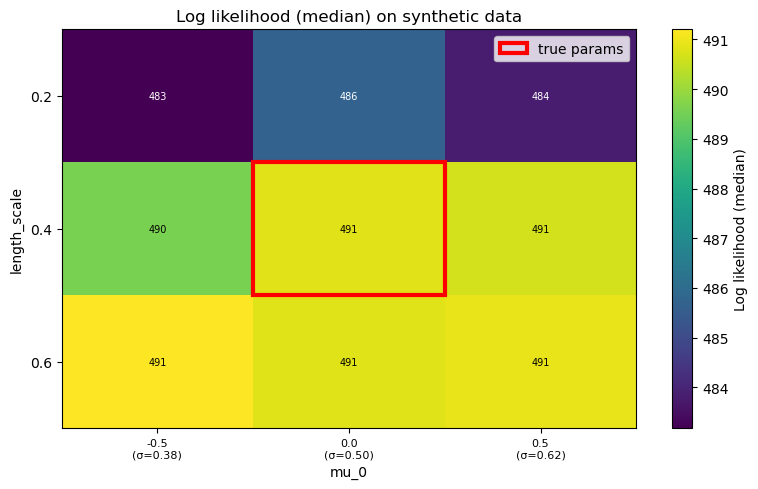

True:  ls=0.4,  mu_0=0.0
Best:  ls=0.6,  mu_0=-0.5,  log_lik=491.2
Recovered correctly: False


In [9]:
ll_grid = np.array([r['log_lik'] for r in results]).reshape(len(LENGTH_SCALES), len(MU_0_VALS))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ll_grid, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(MU_0_VALS)))
ax.set_xticklabels([f"{m}\n(σ={1/(1+np.exp(-m)):.2f})" for m in MU_0_VALS], fontsize=8)
ax.set_yticks(range(len(LENGTH_SCALES)))
ax.set_yticklabels(LENGTH_SCALES)
ax.set_xlabel("mu_0")
ax.set_ylabel('length_scale')
ax.set_title('Log likelihood (median) on synthetic data')
plt.colorbar(im, ax=ax, label='Log likelihood (median)')
for i in range(len(LENGTH_SCALES)):
    for j in range(len(MU_0_VALS)):
        ax.text(j, i, format(ll_grid[i, j], '.0f'), ha='center', va='center',
                fontsize=7, color='white' if ll_grid[i, j] < ll_grid.mean() else 'black')

# Mark true params
true_ls_idx  = LENGTH_SCALES.index(TRUE_PARAMS['length_scale'])
true_mu0_idx = MU_0_VALS.index(TRUE_PARAMS['mu_0'])
ax.add_patch(plt.Rectangle((true_mu0_idx - 0.5, true_ls_idx - 0.5), 1, 1,
                             fill=False, edgecolor='red', lw=3, label='true params'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

best = max(results, key=lambda r: r['log_lik'])
print(f"True:  ls={TRUE_PARAMS['length_scale']},  mu_0={TRUE_PARAMS['mu_0']}")
print(f"Best:  ls={best['length_scale']},  mu_0={best['mu_0']},  log_lik={best['log_lik']:.1f}")
print(f"Recovered correctly: {best['length_scale'] == TRUE_PARAMS['length_scale'] and best['mu_0'] == TRUE_PARAMS['mu_0']}")